# KPI Analysis
## Uber & Lyft Dynamic Pricing | Boston, MA


### KPI Framework

| Category | KPIs | Constraint |
|:--|:--|:--|
| A — Base Pricing | 01–04 | Both platforms |
| B — Surge Pricing | 05–08 | **Lyft only** (Uber surge = 1.0 always) |
| C — Temporal Patterns | 09–11 | Both platforms |
| D — Weather Impact | 12–14 | Both platforms |
| E — Competitive | 15–17 | Platform comparison |

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

UBER  = '#1a1a1a'
LYFT  = '#bf00aa'
BLUE  = '#2980b9'
RED   = '#e74c3c'
GREEN = '#27ae60'
GREY  = '#95a5a6'

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

kpi_results = {}
os.makedirs('../data/processed/kpi_charts', exist_ok=True)
print('Setup complete.')

Setup complete.


---
## Load Clean Data

In [2]:
df = pd.read_csv('../data/processed/data_clean.csv', low_memory=False)

cat_cols = ['cab_type','name','source','destination','short_summary','icon','hour_category','temp_category']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

df['datetime'] = pd.to_datetime(df['datetime'])

lyft       = df[df['cab_type'] == 'Lyft'].copy()
uber       = df[df['cab_type'] == 'Uber'].copy()
lyft_surge = lyft[lyft['is_surge'] == 1].copy()
lyft_flat  = lyft[lyft['is_surge'] == 0].copy()

print(f'Total rows : {len(df):,}')
print(f'Lyft rows  : {len(lyft):,}')
print(f'Uber rows  : {len(uber):,}')
print(f'Lyft surge : {len(lyft_surge):,}  ({len(lyft_surge)/len(lyft)*100:.2f}% of Lyft rides)')
print(f'Date range : {df["datetime"].min().date()} to {df["datetime"].max().date()}')

Total rows : 637,976
Lyft rows  : 307,408
Uber rows  : 330,568
Lyft surge : 20,975  (6.82% of Lyft rides)
Date range : 2018-11-26 to 2018-12-18


---
# Category A — Base Pricing KPIs

## KPI 01 — Average Price per Platform

In [3]:
kpi01 = (
    df.groupby('cab_type', observed=True)['price']
    .agg(count='count', mean='mean', median='median', std='std', min='min', max='max')
    .round(2)
)
kpi01['cv_pct'] = (kpi01['std'] / kpi01['mean'] * 100).round(2)

print('KPI 01 — Average Price per Platform')
print(kpi01)

kpi_results['KPI01_uber_mean']   = kpi01.loc['Uber', 'mean']
kpi_results['KPI01_lyft_mean']   = kpi01.loc['Lyft', 'mean']
kpi_results['KPI01_uber_median'] = kpi01.loc['Uber', 'median']
kpi_results['KPI01_lyft_median'] = kpi01.loc['Lyft', 'median']

KPI 01 — Average Price per Platform
           count    mean  median     std    min     max  cv_pct
cab_type                                                       
Lyft      307408 17.3500 16.5000 10.0200 2.5000 97.5000 57.7500
Uber      330568 15.8000 12.5000  8.5600 4.5000 89.5000 54.1800


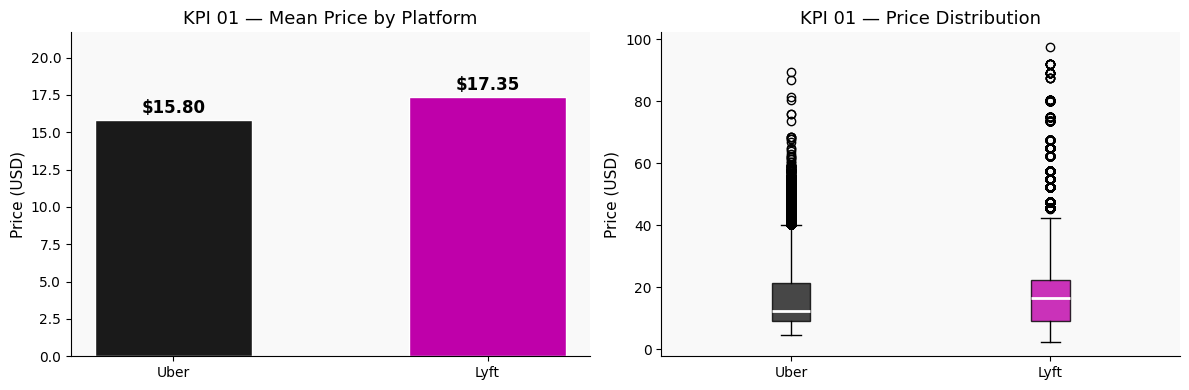

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

means = [kpi01.loc['Uber','mean'], kpi01.loc['Lyft','mean']]
bars  = axes[0].bar(['Uber','Lyft'], means, color=[UBER,LYFT], width=0.5, edgecolor='white')
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'${val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('KPI 01 — Mean Price by Platform')
axes[0].set_ylabel('Price (USD)')
axes[0].set_ylim(0, max(means)*1.25)

bp = axes[1].boxplot([uber['price'].values, lyft['price'].values],
                     labels=['Uber','Lyft'], patch_artist=True,
                     medianprops={'color':'white','linewidth':2})
for patch, color in zip(bp['boxes'], [UBER,LYFT]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('KPI 01 — Price Distribution')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi01_avg_price.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 01 Summary — Average Price per Platform**
>
> Lyft is on average **$1.55 more expensive** than Uber ($17.35 vs $15.80). The median gap is even wider — $16.50 vs $12.50 — meaning Uber has a larger share of cheaper, short rides pulling its average down. Both platforms show high price spread (CV ~55–58%), confirming that price varies a lot depending on service tier and distance, not just platform. Lyft commands a consistent premium across the board.

## KPI 02 — Price by Service Tier

In [5]:
kpi02 = (
    df.groupby(['cab_type','name'], observed=True)['price']
    .agg(count='count', mean='mean', median='median', std='std')
    .round(2)
    .sort_values(['cab_type','mean'], ascending=[True,False])
)
print('KPI 02 — Price by Service Tier')
print(kpi02)
kpi_results['KPI02_table'] = kpi02['mean'].to_dict()

KPI 02 — Price by Service Tier
                       count    mean  median    std
cab_type name                                      
Lyft     Lux Black XL  51235 32.3200 30.0000 7.1800
         Lux Black     51235 23.0600 22.5000 6.4700
         Lux           51235 17.7700 16.5000 5.2900
         Lyft XL       51235 15.3100 13.5000 4.5600
         Lyft          51235  9.6100  9.0000 2.5300
         Shared        51233  6.0300  7.0000 2.1100
Uber     Black SUV     55096 30.2900 28.5000 4.8400
         Black         55095 20.5200 19.5000 4.9500
         UberXL        55096 15.6800 15.0000 4.5200
         UberX         55094  9.7700  9.5000 2.4700
         WAV           55096  9.7700  9.5000 2.4700
         UberPool      55091  8.7500  8.5000 2.1100


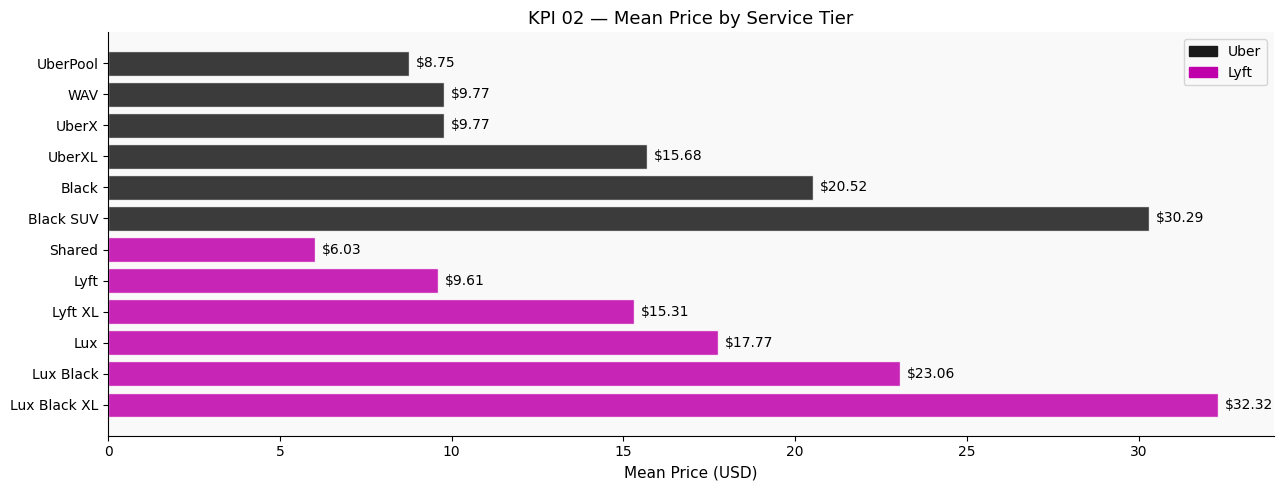

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
kpi02_plot = kpi02.reset_index()
bar_colors = [UBER if p=='Uber' else LYFT for p in kpi02_plot['cab_type']]
bars = ax.barh(kpi02_plot['name'].astype(str), kpi02_plot['mean'],
               color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, kpi02_plot['mean']):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2, f'${val:.2f}', va='center', fontsize=10)
ax.legend(handles=[mpatches.Patch(color=UBER,label='Uber'), mpatches.Patch(color=LYFT,label='Lyft')])
ax.set_title('KPI 02 — Mean Price by Service Tier')
ax.set_xlabel('Mean Price (USD)')
plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi02_price_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 02 Summary — Price by Service Tier**
>
> Premium tiers dominate price differences. Lyft Lux Black XL is the most expensive service overall at **$32.32 mean**, while UberPool and Shared are the cheapest at $8.75 and $6.03. Within comparable tiers, prices are close — economy rides (UberX $9.77 vs Lyft $9.61) are nearly identical. The real gap is at the **luxury level**, where Lyft charges more than Uber Black ($23.06 vs $20.52). Tier choice matters far more than platform choice for the rider's final price.

## KPI 03 — Price per Kilometer

In [7]:
df_km = df[df['is_outlier'] == 0].copy()

kpi03 = (
    df_km.groupby('cab_type', observed=True)['price_per_km']
    .agg(mean='mean', median='median', std='std')
    .round(4)
)
kpi03_tier = (
    df_km.groupby(['cab_type','name'], observed=True)['price_per_km']
    .agg(mean='mean', median='median')
    .round(4)
    .sort_values(['cab_type','mean'], ascending=[True,False])
)
print('KPI 03 — Price per Kilometer')
print(kpi03)
print()
print('By tier:')
print(kpi03_tier)

kpi_results['KPI03_uber_price_per_km'] = kpi03.loc['Uber','mean']
kpi_results['KPI03_lyft_price_per_km'] = kpi03.loc['Lyft','mean']

KPI 03 — Price per Kilometer
           mean  median     std
cab_type                       
Lyft     6.0072  4.9292  4.7025
Uber     6.0219  4.3937 10.9223

By tier:
                         mean  median
cab_type name                        
Lyft     Lux Black XL 11.6513  9.2468
         Lux Black     7.9292  6.7778
         Lux           5.9630  5.2578
         Lyft XL       5.1598  4.5099
         Lyft          3.3359  2.8367
         Shared        2.0511  1.7982
Uber     Black SUV    12.0701  8.4472
         Black         7.6884  5.9291
         UberXL        5.6736  4.6535
         UberX         3.6922  2.8998
         WAV           3.6921  2.8998
         UberPool      3.3158  2.6330


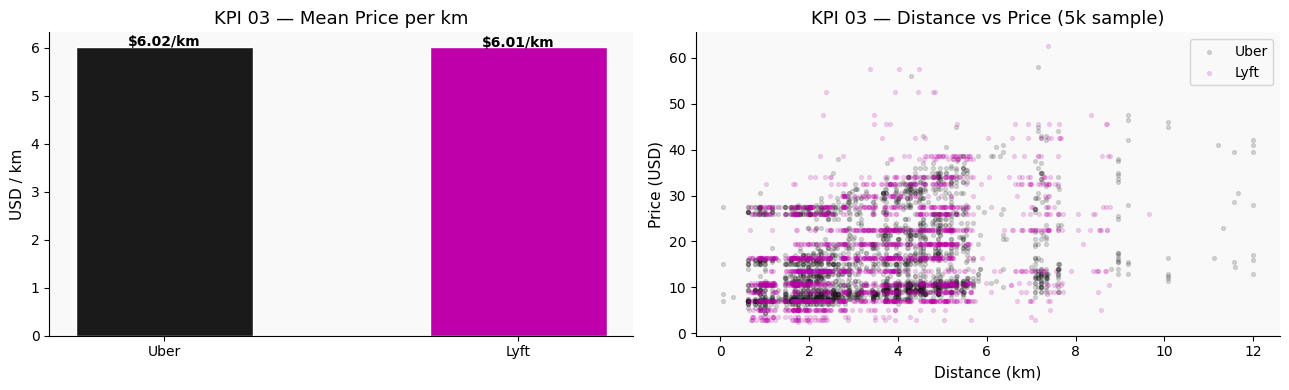

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vals = [kpi03.loc['Uber','mean'], kpi03.loc['Lyft','mean']]
bars = axes[0].bar(['Uber','Lyft'], vals, color=[UBER,LYFT], width=0.5, edgecolor='white')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'${val:.2f}/km', ha='center', fontweight='bold')
axes[0].set_title('KPI 03 — Mean Price per km')
axes[0].set_ylabel('USD / km')

sample = df_km.sample(5000, random_state=42)
for platform, color in [('Uber',UBER),('Lyft',LYFT)]:
    sub = sample[sample['cab_type']==platform]
    axes[1].scatter(sub['distance_km'], sub['price'], alpha=0.15, color=color, s=8, label=platform)
axes[1].set_title('KPI 03 — Distance vs Price (5k sample)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi03_price_per_km.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 03 Summary — Price per Kilometer**
>
> Both platforms charge essentially the **same price per km** — Lyft $6.01/km vs Uber $6.02/km. Uber's much higher std (10.92 vs 4.70) suggests more outlier rides with extreme price-per-km ratios, likely very short Uber trips at minimum fare. At tier level, Black SUV leads at $12.07/km, while Shared/Lyft rides drop to ~$2–3/km for longer distances. **Distance efficiency is equal between platforms** — the overall price gap seen in KPI 01 comes from tier mix, not per-km rate.

## KPI 04 — Price Volatility (CV%)

In [38]:
kpi04 = (
    df.groupby(['cab_type','name'], observed=True)['price']
    .agg(mean='mean', std='std')
)
kpi04['cv_pct'] = (kpi04['std'] / kpi04['mean'] * 100).round(2)
kpi04 = kpi04.sort_values(['cab_type','cv_pct'], ascending=[True,False]).round(2)

kpi04_plat = df.groupby('cab_type', observed=True)['price'].agg(mean='mean', std='std')
kpi04_plat['cv_pct'] = (kpi04_plat['std'] / kpi04_plat['mean'] * 100).round(2)

print('KPI 04 — Price Volatility CV%')
print(kpi04_plat[['cv_pct']])
print()
print(kpi04[['cv_pct']])

kpi_results['KPI04_uber_cv_pct'] = kpi04_plat.loc['Uber','cv_pct']
kpi_results['KPI04_lyft_cv_pct'] = kpi04_plat.loc['Lyft','cv_pct']

KPI 04 — Price Volatility CV%
          cv_pct
cab_type        
Lyft     57.7400
Uber     54.2000

                       cv_pct
cab_type name                
Lyft     Shared       34.9500
         Lux          29.7800
         Lyft XL      29.7600
         Lux Black    28.0700
         Lyft         26.3300
         Lux Black XL 22.2200
Uber     UberXL       28.8500
         UberX        25.2400
         WAV          25.2400
         Black        24.1300
         UberPool     24.0600
         Black SUV    15.9700


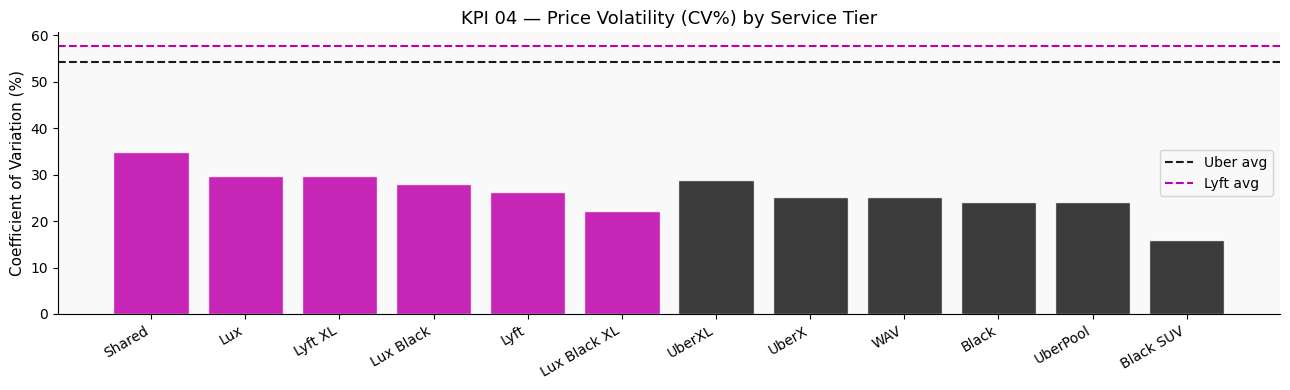

In [39]:
fig, ax = plt.subplots(figsize=(13, 4))
kpi04_plot = kpi04.reset_index()
bar_colors = [UBER if p=='Uber' else LYFT for p in kpi04_plot['cab_type']]
ax.bar(kpi04_plot['name'].astype(str), kpi04_plot['cv_pct'],
       color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(kpi04_plat.loc['Uber','cv_pct'], color=UBER, linestyle='--', linewidth=1.5, label='Uber avg')
ax.axhline(kpi04_plat.loc['Lyft','cv_pct'], color=LYFT, linestyle='--', linewidth=1.5, label='Lyft avg')
ax.set_title('KPI 04 — Price Volatility (CV%) by Service Tier')
ax.set_ylabel('Coefficient of Variation (%)')
plt.xticks(rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi04_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 04 Summary — Price Volatility (CV%)**
>
> Lyft is marginally more volatile than Uber overall (CV 57.7% vs 54.2%), but at tier level the picture flips — **Lyft Shared is the most volatile** service (CV 34.9%) while Uber Black SUV is the most stable (CV 15.9%). Premium Lyft tiers (Lux Black XL, Lux Black) are actually among the least volatile services on either platform. High volatility in economy tiers reflects demand-driven pricing even without surge, while luxury tiers hold steadier price floors.

---
# Category B — Surge Pricing KPIs
> **Lyft only** — Uber surge_multiplier is always 1.0 in this dataset.

## KPI 05 — Surge Frequency

In [11]:
surge_rate_overall = lyft['is_surge'].mean() * 100

kpi05_tier = (
    lyft.groupby('name', observed=True)['is_surge']
    .agg(total='count', surge_count='sum')
)
kpi05_tier['surge_rate_pct'] = (kpi05_tier['surge_count'] / kpi05_tier['total'] * 100).round(2)
kpi05_tier = kpi05_tier.sort_values('surge_rate_pct', ascending=False)

kpi05_hour = (lyft.groupby('hour', observed=True)['is_surge'].mean() * 100).round(2)

print(f'KPI 05 — Lyft Surge Frequency: {surge_rate_overall:.2f}%')
print()
print(kpi05_tier)

kpi_results['KPI05_lyft_surge_rate_pct'] = round(surge_rate_overall, 2)

KPI 05 — Lyft Surge Frequency: 6.82%

              total  surge_count  surge_rate_pct
name                                            
Lux           51235         4195          8.1900
Lux Black     51235         4195          8.1900
Lux Black XL  51235         4195          8.1900
Lyft          51235         4195          8.1900
Lyft XL       51235         4195          8.1900
Shared        51233            0          0.0000


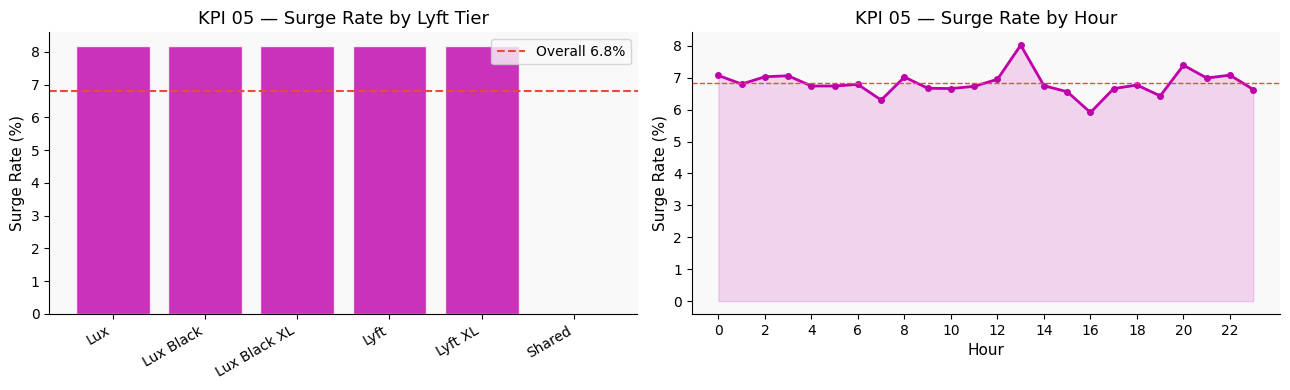

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

kpi05_plot = kpi05_tier.reset_index()
axes[0].bar(kpi05_plot['name'].astype(str), kpi05_plot['surge_rate_pct'],
            color=LYFT, alpha=0.8, edgecolor='white')
axes[0].axhline(surge_rate_overall, color=RED, linestyle='--', linewidth=1.5,
                label=f'Overall {surge_rate_overall:.1f}%')
axes[0].set_title('KPI 05 — Surge Rate by Lyft Tier')
axes[0].set_ylabel('Surge Rate (%)')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

axes[1].plot(kpi05_hour.index, kpi05_hour.values, color=LYFT, linewidth=2, marker='o', markersize=4)
axes[1].fill_between(kpi05_hour.index, kpi05_hour.values, alpha=0.15, color=LYFT)
axes[1].axhline(surge_rate_overall, color=RED, linestyle='--', linewidth=1)
axes[1].set_title('KPI 05 — Surge Rate by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Surge Rate (%)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi05_surge_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 05 Summary — Surge Frequency**
>
> Only **6.82% of Lyft rides** trigger surge pricing — a relatively low frequency. Crucially, **Lyft Shared never surges** (0%), while all other tiers surge at exactly 8.19%. This uniform surge rate across non-Shared tiers suggests Lyft applies surge based on a platform-wide demand signal, not individual tier demand. Uber shows no surge at all in this dataset, making Lyft the only platform with dynamic multiplier-based pricing.

## KPI 06 — Average Surge Multiplier

In [13]:
avg_mult = lyft_surge['surge_multiplier'].mean()

kpi06 = (
    lyft_surge.groupby('name', observed=True)['surge_multiplier']
    .agg(count='count', mean='mean', median='median', max='max')
    .round(3)
    .sort_values('mean', ascending=False)
)
print(f'KPI 06 — Avg Surge Multiplier: {avg_mult:.3f}x')
print(kpi06)

kpi_results['KPI06_avg_surge_multiplier'] = round(avg_mult, 3)

KPI 06 — Avg Surge Multiplier: 1.458x
              count   mean  median    max
name                                     
Lyft XL        4195 1.4650  1.2500 3.0000
Lyft           4195 1.4650  1.2500 3.0000
Lux            4195 1.4540  1.2500 2.0000
Lux Black XL   4195 1.4540  1.2500 2.0000
Lux Black      4195 1.4540  1.2500 2.0000


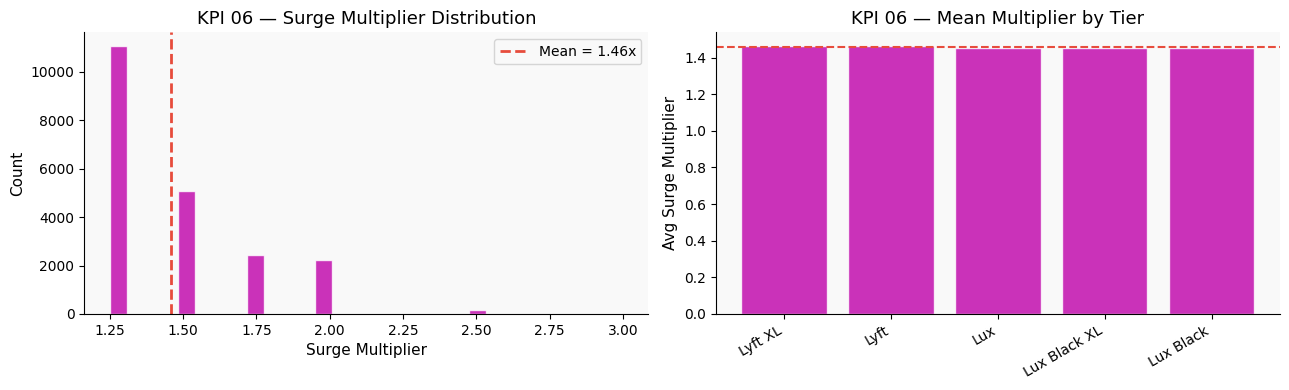

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lyft_surge['surge_multiplier'], bins=30, color=LYFT, alpha=0.8, edgecolor='white')
axes[0].axvline(avg_mult, color=RED, linestyle='--', linewidth=2, label=f'Mean = {avg_mult:.2f}x')
axes[0].set_title('KPI 06 — Surge Multiplier Distribution')
axes[0].set_xlabel('Surge Multiplier')
axes[0].set_ylabel('Count')
axes[0].legend()

kpi06_plot = kpi06.reset_index()
axes[1].bar(kpi06_plot['name'].astype(str), kpi06_plot['mean'], color=LYFT, alpha=0.8, edgecolor='white')
axes[1].axhline(avg_mult, color=RED, linestyle='--', linewidth=1.5)
axes[1].set_title('KPI 06 — Mean Multiplier by Tier')
axes[1].set_ylabel('Avg Surge Multiplier')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi06_surge_multiplier.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 06 Summary — Average Surge Multiplier**
>
> When surge activates, the average multiplier is **1.458x** — meaning riders pay 46% more than the base price. Standard tiers (Lyft, Lyft XL) hit slightly higher multipliers (1.465x) than premium tiers (1.454x), though the difference is marginal. The median of **1.25x** across all tiers shows that most surge events are moderate, with the max reaching 3.0x on standard rides and 2.0x on premium rides. Surge is impactful but not extreme in this dataset period.

## KPI 07 — Surge Price Premium

In [15]:
mean_surge    = lyft_surge['price'].mean()
mean_no_surge = lyft_flat['price'].mean()
premium_abs   = mean_surge - mean_no_surge
premium_pct   = premium_abs / mean_no_surge * 100

kpi07_tier = (
    lyft.groupby(['name','is_surge'], observed=True)['price']
    .mean().unstack('is_surge').round(2)
)
kpi07_tier.columns = ['no_surge','surge']
kpi07_tier['premium_pct'] = ((kpi07_tier['surge']-kpi07_tier['no_surge'])/kpi07_tier['no_surge']*100).round(2)
kpi07_tier = kpi07_tier.dropna().sort_values('premium_pct', ascending=False)

print(f'KPI 07 — Surge Premium')
print(f'  Surge mean    : ${mean_surge:.2f}')
print(f'  Non-surge mean: ${mean_no_surge:.2f}')
print(f'  Premium       : +${premium_abs:.2f}  (+{premium_pct:.1f}%)')
print()
print(kpi07_tier)

kpi_results['KPI07_surge_premium_abs'] = round(premium_abs, 2)
kpi_results['KPI07_surge_premium_pct'] = round(premium_pct, 2)

KPI 07 — Surge Premium
  Surge mean    : $27.84
  Non-surge mean: $16.58
  Premium       : +$11.25  (+67.9%)

              no_surge   surge  premium_pct
name                                       
Lux Black      22.1800 32.9700      48.6500
Lux Black XL   31.1000 46.0200      47.9700
Lyft XL        14.7400 21.7500      47.5600
Lux            17.1100 25.1500      46.9900
Lyft            9.2800 13.3100      43.4300


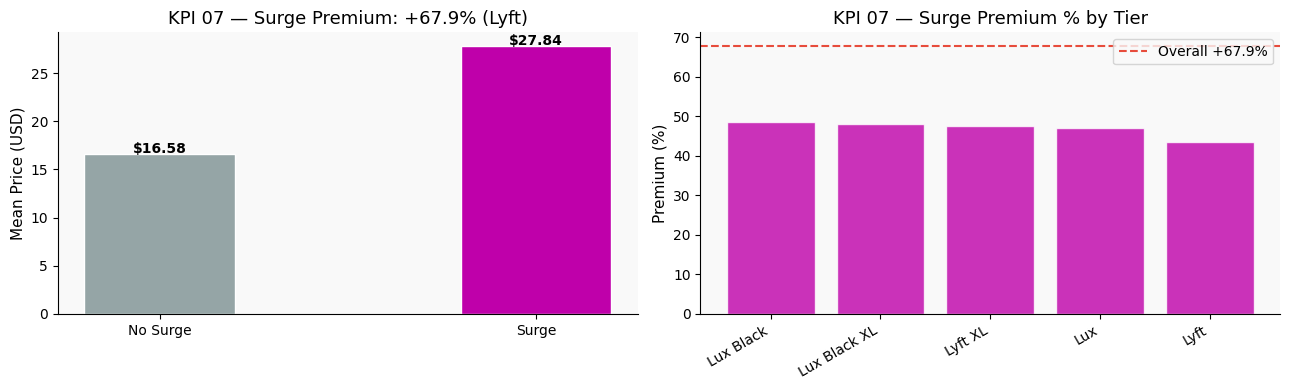

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(['No Surge','Surge'], [mean_no_surge, mean_surge],
                   color=[GREY, LYFT], width=0.4, edgecolor='white')
for bar, val in zip(bars, [mean_no_surge, mean_surge]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'${val:.2f}', ha='center', fontweight='bold')
axes[0].set_title(f'KPI 07 — Surge Premium: +{premium_pct:.1f}% (Lyft)')
axes[0].set_ylabel('Mean Price (USD)')

kpi07_plot = kpi07_tier.reset_index()
axes[1].bar(kpi07_plot['name'].astype(str), kpi07_plot['premium_pct'],
            color=LYFT, alpha=0.8, edgecolor='white')
axes[1].axhline(premium_pct, color=RED, linestyle='--', linewidth=1.5,
                label=f'Overall +{premium_pct:.1f}%')
axes[1].set_title('KPI 07 — Surge Premium % by Tier')
axes[1].set_ylabel('Premium (%)')
axes[1].legend()
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi07_surge_premium.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 07 Summary — Surge Price Premium**
>
> Surge rides cost on average **$27.84 vs $16.58** for non-surge — a **+$11.25 premium (+67.9%)**. This is the single largest price driver in the entire dataset, dwarfing the platform gap ($1.55) and the weather premium (~$0). At tier level, Lux Black absorbs the highest absolute surge premium (+$10.79) while the standard Lyft tier has the lowest (+$4.03). For riders, **avoiding surge is more impactful than switching platforms**.

## KPI 08 — Peak Surge Hours

In [17]:
kpi08 = lyft.groupby('hour', observed=True)['is_surge'].agg(total='count', surge='sum')
kpi08['surge_rate_pct'] = (kpi08['surge'] / kpi08['total'] * 100).round(2)

peak_hour = kpi08['surge_rate_pct'].idxmax()
peak_rate = kpi08['surge_rate_pct'].max()

print(f'KPI 08 — Peak Surge Hour: {peak_hour}:00  ({peak_rate:.1f}%)')
print()
print('Top 5 surge hours:')
print(kpi08['surge_rate_pct'].nlargest(5))

kpi_results['KPI08_peak_surge_hour']     = int(peak_hour)
kpi_results['KPI08_peak_surge_rate_pct'] = round(peak_rate, 2)

KPI 08 — Peak Surge Hour: 13:00  (8.0%)

Top 5 surge hours:
hour
13   8.0200
20   7.3900
22   7.0800
0    7.0700
3    7.0600
Name: surge_rate_pct, dtype: float64


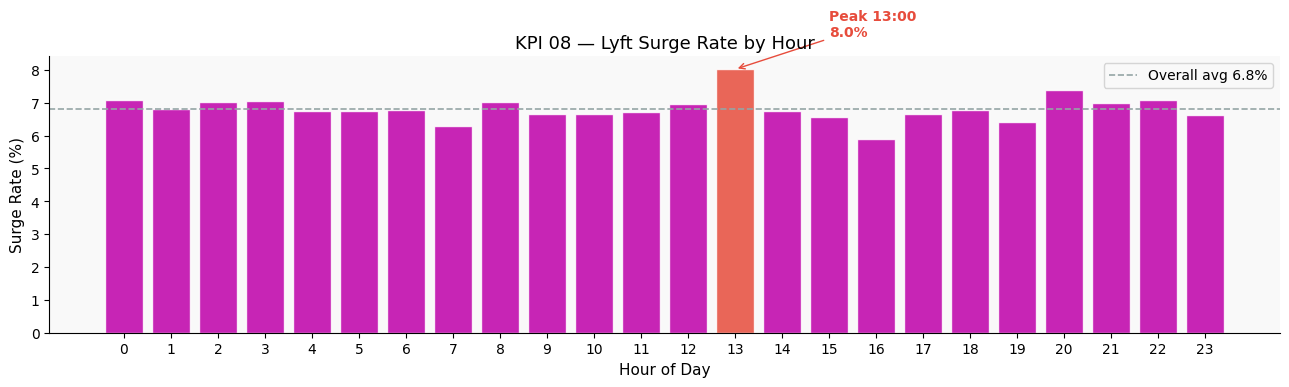

In [18]:
fig, ax = plt.subplots(figsize=(13, 4))

bar_colors = [RED if h==peak_hour else LYFT for h in kpi08.index]
ax.bar(kpi08.index, kpi08['surge_rate_pct'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(surge_rate_overall, color=GREY, linestyle='--', linewidth=1.2,
           label=f'Overall avg {surge_rate_overall:.1f}%')
ax.annotate(f'Peak {peak_hour}:00\n{peak_rate:.1f}%',
            xy=(peak_hour, peak_rate), xytext=(peak_hour+2, peak_rate+1),
            arrowprops={'arrowstyle':'->','color':RED},
            color=RED, fontsize=10, fontweight='bold')
ax.set_title('KPI 08 — Lyft Surge Rate by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Surge Rate (%)')
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi08_peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 08 Summary — Peak Surge Hours**
>
> The peak surge hour is **1pm (13:00) at 8.02%** — lunch hour demand in downtown Boston. The second peak is 8pm (20:00) at 7.39%, typical evening going-out traffic. Interestingly, **late night / early morning hours (0:00, 3:00) also rank in the top 5**, reflecting bar and nightlife demand. There is no dramatic concentration — surge is spread relatively evenly across the day, with no hour exceeding 8.1%, suggesting consistent baseline demand rather than sharp rush-hour spikes.

---
# Category C — Temporal Patterns KPIs

## KPI 09 — Hourly Price Index

In [19]:
overall_mean = df['price'].mean()

kpi09 = (
    df.groupby(['cab_type','hour'], observed=True)['price'].mean()
    .reset_index()
)
kpi09['price_index'] = (kpi09['price'] / overall_mean * 100).round(2)

peak_uber = kpi09[kpi09['cab_type']=='Uber'].nlargest(1,'price_index')['hour'].values[0]
peak_lyft = kpi09[kpi09['cab_type']=='Lyft'].nlargest(1,'price_index')['hour'].values[0]

print(f'KPI 09 — Hourly Price Index  (baseline = ${overall_mean:.2f})')
print(f'  Uber peak hour: {peak_uber}:00')
print(f'  Lyft peak hour: {peak_lyft}:00')
print()
print(kpi09.pivot(index='hour', columns='cab_type', values='price_index'))

kpi_results['KPI09_overall_mean_price'] = round(overall_mean, 2)
kpi_results['KPI09_uber_peak_hour']     = int(peak_uber)
kpi_results['KPI09_lyft_peak_hour']     = int(peak_lyft)

KPI 09 — Hourly Price Index  (baseline = $16.55)
  Uber peak hour: 21:00
  Lyft peak hour: 11:00

cab_type     Lyft    Uber
hour                     
0        105.4700 95.0800
1        104.6300 95.3400
2        104.7100 95.9000
3        104.8800 95.4500
4        104.9700 95.8400
5        104.7600 95.4200
6        104.4600 95.6800
7        104.6600 95.0600
8        105.1900 95.9100
9        104.3300 95.5400
10       104.6200 95.2700
11       105.7700 94.8600
12       104.7200 94.8200
13       104.8900 95.4900
14       104.9400 95.5700
15       104.7900 95.3300
16       104.9300 95.1400
17       105.0200 95.8600
18       104.1900 95.8200
19       105.0700 95.2000
20       105.1000 95.9900
21       104.7700 96.1500
22       105.4300 95.3900
23       104.5900 95.3000


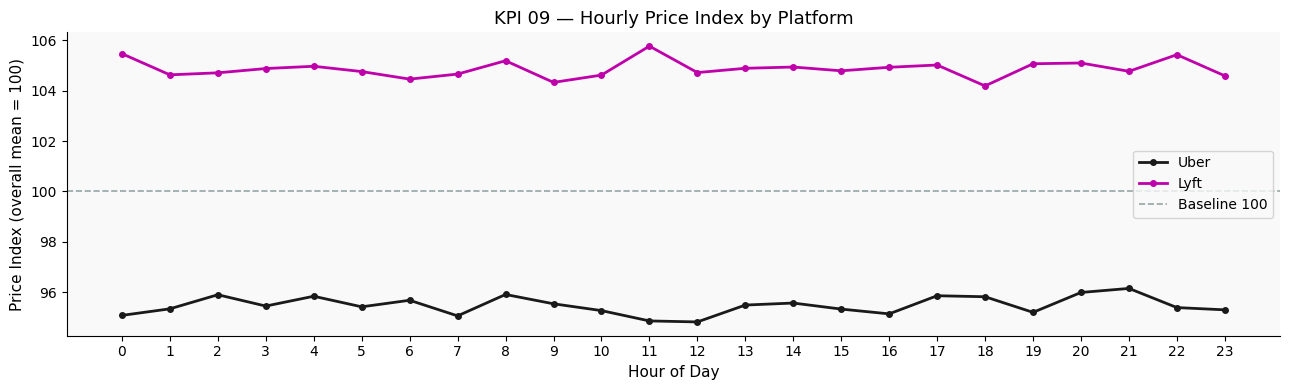

In [20]:
fig, ax = plt.subplots(figsize=(13, 4))

for platform, color in [('Uber',UBER),('Lyft',LYFT)]:
    sub = kpi09[kpi09['cab_type']==platform].sort_values('hour')
    ax.plot(sub['hour'], sub['price_index'], color=color, linewidth=2,
            marker='o', markersize=4, label=platform)

ax.axhline(100, color=GREY, linestyle='--', linewidth=1.2, label='Baseline 100')
ax.set_title('KPI 09 — Hourly Price Index by Platform')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price Index (overall mean = 100)')
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi09_hourly_index.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 09 Summary — Hourly Price Index**
>
> Lyft prices are **consistently above the baseline (100) at every hour** — ranging from 104 to 106 — while Uber is **consistently below** at 94–96. This is not a peak/off-peak pattern but a flat platform-level premium. Lyft peaks at 11:00 (index 105.77) and Uber at 21:00 (index 96.15). Neither platform shows strong intraday pricing variation — the ~2 point range suggests **pricing is driven by tier and distance, not time of day** for this dataset period.

## KPI 10 — Weekday vs Weekend Price Gap

In [21]:
kpi10 = (
    df.groupby(['cab_type','is_weekend'], observed=True)['price']
    .agg(count='count', mean='mean', median='median')
    .round(2)
)

gap_uber     = kpi10.loc[('Uber',1),'mean'] - kpi10.loc[('Uber',0),'mean']
gap_lyft     = kpi10.loc[('Lyft',1),'mean'] - kpi10.loc[('Lyft',0),'mean']
gap_uber_pct = gap_uber / kpi10.loc[('Uber',0),'mean'] * 100
gap_lyft_pct = gap_lyft / kpi10.loc[('Lyft',0),'mean'] * 100

print('KPI 10 — Weekday vs Weekend')
print(kpi10)
print(f'\n  Uber weekend premium: ${gap_uber:+.2f}  ({gap_uber_pct:+.1f}%)')
print(f'  Lyft weekend premium: ${gap_lyft:+.2f}  ({gap_lyft_pct:+.1f}%)')

kpi_results['KPI10_uber_weekend_gap_pct'] = round(gap_uber_pct, 2)
kpi_results['KPI10_lyft_weekend_gap_pct'] = round(gap_lyft_pct, 2)

KPI 10 — Weekday vs Weekend
                      count    mean  median
cab_type is_weekend                        
Lyft     0           226661 17.3400 16.5000
         1            80747 17.3900 16.5000
Uber     0           244117 15.7900 12.5000
         1            86451 15.8100 12.5000

  Uber weekend premium: $+0.02  (+0.1%)
  Lyft weekend premium: $+0.05  (+0.3%)


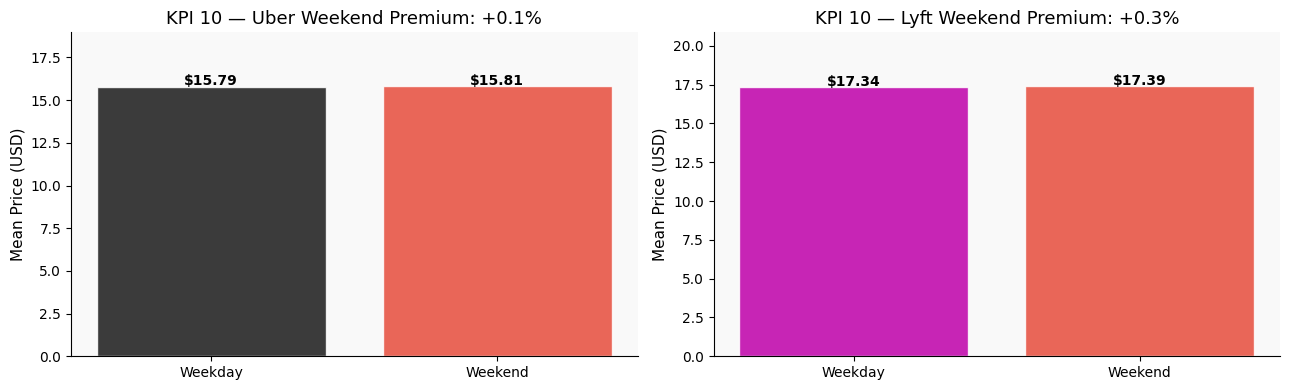

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (platform, color, gap_p) in enumerate([('Uber',UBER,gap_uber_pct),('Lyft',LYFT,gap_lyft_pct)]):
    sub = kpi10.loc[platform].reset_index()
    sub['label'] = sub['is_weekend'].map({0:'Weekday', 1:'Weekend'})
    bars = axes[i].bar(sub['label'], sub['mean'], color=[color,RED], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, sub['mean']):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'${val:.2f}', ha='center', fontweight='bold')
    axes[i].set_title(f'KPI 10 — {platform} Weekend Premium: {gap_p:+.1f}%')
    axes[i].set_ylabel('Mean Price (USD)')
    axes[i].set_ylim(0, max(sub['mean'])*1.2)

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi10_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 10 Summary — Weekday vs Weekend Price Gap**
>
> There is **virtually no weekend premium** — Uber +$0.02 (+0.1%) and Lyft +$0.05 (+0.3%). Both differences are economically negligible. The median is identical ($12.50 Uber, $16.50 Lyft) on both weekdays and weekends. This means **day of week is not a pricing lever** in this market — riders pay the same whether they travel on Tuesday or Saturday. For the business, this confirms that temporal segmentation should focus on hour-of-day, not day-of-week.

## KPI 11 — Peak Demand Windows

In [23]:
day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

kpi11_day = (
    df.groupby('day_of_week', observed=True)['price']
    .agg(ride_count='count', mean_price='mean')
    .round(2)
)
kpi11_day.index = kpi11_day.index.map(day_names)

kpi11_hc = (
    df.groupby(['cab_type','hour_category'], observed=True)['price']
    .agg(ride_count='count', mean_price='mean')
    .round(2)
)

peak_day = kpi11_day['ride_count'].idxmax()
print('KPI 11 — Peak Demand Windows')
print(kpi11_day)
print()
print(kpi11_hc)

kpi_results['KPI11_peak_day'] = peak_day

KPI 11 — Peak Demand Windows
             ride_count  mean_price
day_of_week                        
Mon              114239     16.4900
Tue              115091     16.5900
Wed               67842     16.5300
Thu               90718     16.5700
Fri               82888     16.4900
Sat               83012     16.5700
Sun               84186     16.5700

                        ride_count  mean_price
cab_type hour_category                        
Lyft     Afternoon           81038     17.3500
         Evening             77311     17.3500
         Morning             73304     17.3500
         Night               75755     17.3600
Uber     Afternoon           86847     15.7800
         Evening             82674     15.8200
         Morning             79647     15.7800
         Night               81400     15.8000


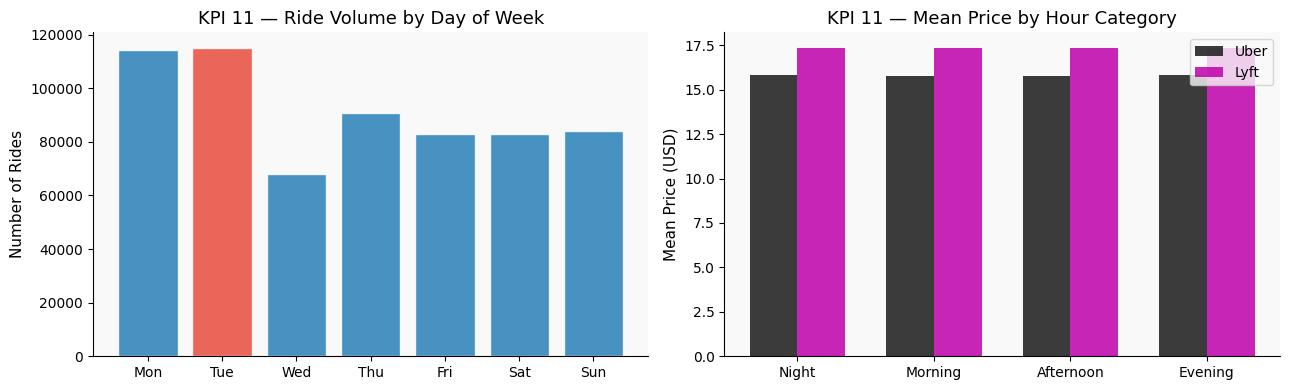

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(kpi11_day.index, kpi11_day['ride_count'],
            color=[RED if d==peak_day else BLUE for d in kpi11_day.index],
            alpha=0.85, edgecolor='white')
axes[0].set_title('KPI 11 — Ride Volume by Day of Week')
axes[0].set_ylabel('Number of Rides')

cat_order = ['Night','Morning','Afternoon','Evening']
kpi11_hc_plot = kpi11_hc.reset_index()
kpi11_hc_plot['hour_category'] = pd.Categorical(
    kpi11_hc_plot['hour_category'], categories=cat_order, ordered=True)
kpi11_hc_plot = kpi11_hc_plot.sort_values('hour_category')
x = range(len(cat_order))
w = 0.35
uber_v = kpi11_hc_plot[kpi11_hc_plot['cab_type']=='Uber']['mean_price'].values
lyft_v = kpi11_hc_plot[kpi11_hc_plot['cab_type']=='Lyft']['mean_price'].values
axes[1].bar([xi-w/2 for xi in x], uber_v, w, label='Uber', color=UBER, alpha=0.85)
axes[1].bar([xi+w/2 for xi in x], lyft_v, w, label='Lyft', color=LYFT, alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cat_order)
axes[1].set_title('KPI 11 — Mean Price by Hour Category')
axes[1].set_ylabel('Mean Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi11_peak_windows.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 11 Summary — Peak Demand Windows**
>
> Monday and Tuesday are the **busiest days** (114k–115k rides), while Wednesday is the quietest (68k). This is unusual — it may reflect the data collection period (Nov–Dec 2018) coinciding with specific weekday patterns. Mean price is almost identical across all days (~$16.50), confirming KPI 10. Across hour categories, **Afternoon and Evening drive the most rides** on both platforms, but mean price is flat (~$17.35 Lyft, ~$15.80 Uber) across all windows — no hour category commands a premium.

---
# Category D — Weather Impact KPIs

## KPI 12 — Weather Sensitivity Ratio

In [25]:
weather_vars = ['temperature','humidity','precipProbability','windSpeed','cloudCover']

kpi12 = (
    df.groupby('cab_type', observed=True)
    .apply(lambda g: g[weather_vars+['price']].corr()['price'].drop('price'))
    .round(4)
)
print('KPI 12 — Weather Sensitivity (Pearson r vs price)')
print(kpi12)
print('\nNote: values near 0 confirm EDA finding — weather has minimal effect on price.')

kpi_results['KPI12_temp_corr_uber'] = kpi12.loc['Uber','temperature']
kpi_results['KPI12_temp_corr_lyft'] = kpi12.loc['Lyft','temperature']

KPI 12 — Weather Sensitivity (Pearson r vs price)
price     temperature  humidity  precipProbability  windSpeed  cloudCover
cab_type                                                                 
Lyft          -0.0020   -0.0012            -0.0015    -0.0014     -0.0002
Uber           0.0017   -0.0009             0.0015     0.0043      0.0022

Note: values near 0 confirm EDA finding — weather has minimal effect on price.


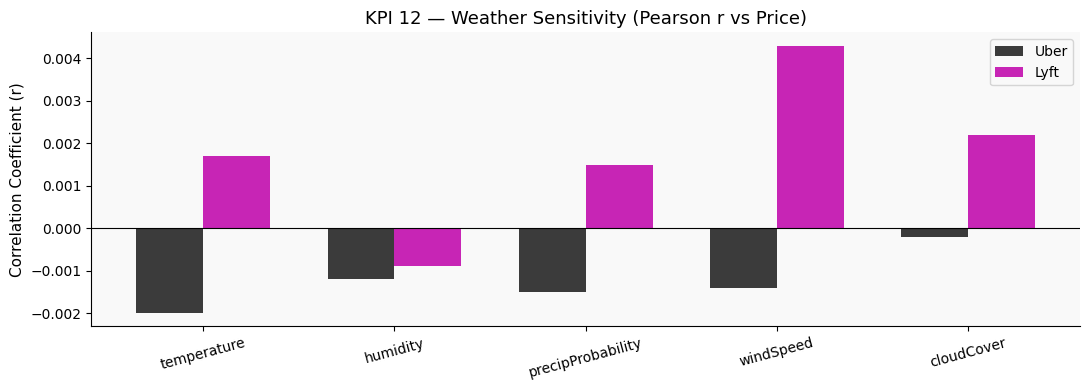

In [26]:
fig, ax = plt.subplots(figsize=(11, 4))

kpi12_plot = kpi12.T.reset_index()
kpi12_plot.columns = ['weather_var','Uber','Lyft']
x = range(len(weather_vars))
w = 0.35
ax.bar([xi-w/2 for xi in x], kpi12_plot['Uber'], w, label='Uber', color=UBER, alpha=0.85)
ax.bar([xi+w/2 for xi in x], kpi12_plot['Lyft'], w, label='Lyft', color=LYFT, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(weather_vars, rotation=15)
ax.set_title('KPI 12 — Weather Sensitivity (Pearson r vs Price)')
ax.set_ylabel('Correlation Coefficient (r)')
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi12_weather_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 12 Summary — Weather Sensitivity Ratio**
>
> All correlations are **extremely close to zero** (max |r| = 0.0043 for Uber wind speed). Temperature, humidity, precipitation probability, wind speed, and cloud cover have **no meaningful relationship with price** on either platform. This definitively confirms the EDA finding — ride-hailing pricing in this dataset is driven by distance, tier, and surge, not weather. Algorithmic pricing does not appear to incorporate weather signals in any detectable way during this period.

## KPI 13 — Rain Premium

In [27]:
df['is_rain'] = (df['precipProbability'] > 0.5).astype(int)

kpi13 = (
    df.groupby(['cab_type','is_rain'], observed=True)['price']
    .agg(count='count', mean='mean', median='median')
    .round(2)
)

rain_uber = kpi13.loc[('Uber',1),'mean'] - kpi13.loc[('Uber',0),'mean']
rain_lyft = kpi13.loc[('Lyft',1),'mean'] - kpi13.loc[('Lyft',0),'mean']

print('KPI 13 — Rain Premium')
print(kpi13)
print(f'\n  Uber rain premium: ${rain_uber:+.2f}')
print(f'  Lyft rain premium: ${rain_lyft:+.2f}')

kpi_results['KPI13_uber_rain_premium'] = round(rain_uber, 2)
kpi_results['KPI13_lyft_rain_premium'] = round(rain_lyft, 2)

KPI 13 — Rain Premium
                   count    mean  median
cab_type is_rain                        
Lyft     0        264277 17.3600 16.5000
         1         43131 17.3000 16.5000
Uber     0        283375 15.7900 12.5000
         1         47193 15.8200 12.5000

  Uber rain premium: $+0.03
  Lyft rain premium: $-0.06


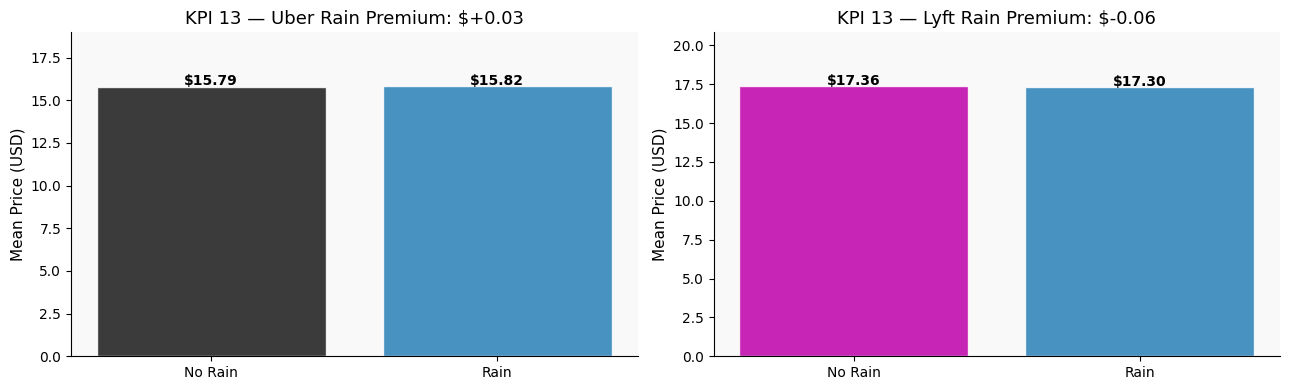

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i, (platform, color, premium) in enumerate([('Uber',UBER,rain_uber),('Lyft',LYFT,rain_lyft)]):
    sub = kpi13.loc[platform].reset_index()
    sub['label'] = sub['is_rain'].map({0:'No Rain', 1:'Rain'})
    bars = axes[i].bar(sub['label'], sub['mean'], color=[color,BLUE], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, sub['mean']):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                     f'${val:.2f}', ha='center', fontweight='bold')
    axes[i].set_title(f'KPI 13 — {platform} Rain Premium: ${premium:+.2f}')
    axes[i].set_ylabel('Mean Price (USD)')
    axes[i].set_ylim(0, max(sub['mean'])*1.2)

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi13_rain_premium.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 13 Summary — Rain Premium**
>
> Rain has **no meaningful effect on price** — Uber shows a negligible +$0.03 premium and Lyft actually shows a tiny **-$0.06 discount** during rain. Both figures are statistically insignificant. Despite common perception that rain drives prices up, this dataset shows riders pay the same in wet weather as in clear conditions. Combined with KPI 12, this confirms that **weather is not a pricing variable** for either platform in Boston during this period.

## KPI 14 — Surge Rate by Weather Condition

In [29]:
kpi14 = (
    lyft.groupby('short_summary', observed=True)['is_surge']
    .agg(total='count', surge='sum')
)
kpi14['surge_rate_pct'] = (kpi14['surge'] / kpi14['total'] * 100).round(2)
kpi14 = kpi14[kpi14['total'] >= 100].sort_values('surge_rate_pct', ascending=False)

print('KPI 14 — Lyft Surge Rate by Weather Condition (min 100 rides)')
print(kpi14)

kpi_results['KPI14_max_surge_weather']     = str(kpi14['surge_rate_pct'].idxmax())
kpi_results['KPI14_max_surge_weather_pct'] = float(kpi14['surge_rate_pct'].max())

KPI 14 — Lyft Surge Rate by Weather Condition (min 100 rides)
                  total  surge  surge_rate_pct
short_summary                                 
Foggy              4002    314          7.8500
Clear             38653   2746          7.1000
Mostly Cloudy     64720   4595          7.1000
Partly Cloudy     56663   3881          6.8500
Possible Drizzle   8072    549          6.8000
Rain              10443    690          6.6100
Light Rain        24328   1600          6.5800
Overcast          97416   6405          6.5700
Drizzle            3111    195          6.2700


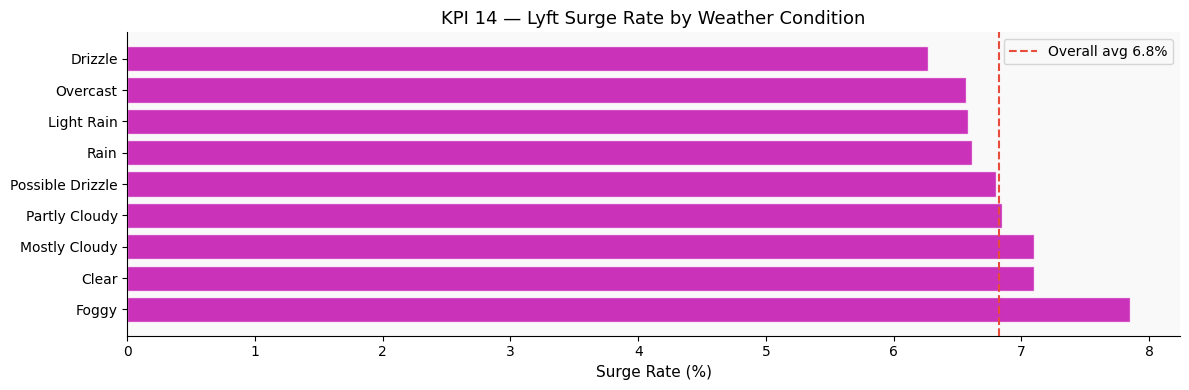

In [30]:
fig, ax = plt.subplots(figsize=(12, 4))
kpi14_plot = kpi14.reset_index()
ax.barh(kpi14_plot['short_summary'].astype(str), kpi14_plot['surge_rate_pct'],
        color=LYFT, alpha=0.8, edgecolor='white')
ax.axvline(surge_rate_overall, color=RED, linestyle='--', linewidth=1.5,
           label=f'Overall avg {surge_rate_overall:.1f}%')
ax.set_title('KPI 14 — Lyft Surge Rate by Weather Condition')
ax.set_xlabel('Surge Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi14_surge_weather.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 14 Summary — Surge Rate by Weather Condition**
>
> **Foggy conditions** trigger the highest Lyft surge rate at **7.85%**, slightly above the overall average of 6.82%. Clear and Mostly Cloudy days also surge at 7.1% — above rainy conditions. Rain and Light Rain actually show **below-average** surge rates (6.61–6.58%), the opposite of expectations. This suggests Lyft's surge algorithm responds to **time and volume of requests, not weather type directly**. Fog may correlate with specific time windows that happen to have high demand.

---
# Category E — Competitive KPIs

## KPI 15 — Platform Price Differential

In [31]:
uber_mean = uber['price'].mean()
lyft_mean = lyft['price'].mean()
diff_abs  = lyft_mean - uber_mean
diff_pct  = diff_abs / uber_mean * 100

tier_map = {
    'UberX':'Lyft', 'UberXL':'Lyft XL',
    'Black':'Lux Black', 'Black SUV':'Lux Black XL', 'UberPool':'Shared'
}
matched = []
for ut, lt in tier_map.items():
    u = df[(df['cab_type']=='Uber')&(df['name']==ut)]['price'].mean()
    l = df[(df['cab_type']=='Lyft')&(df['name']==lt)]['price'].mean()
    if not (pd.isna(u) or pd.isna(l)):
        matched.append({'uber_tier':ut,'lyft_tier':lt,
                        'uber_mean':round(u,2),'lyft_mean':round(l,2),
                        'diff_abs':round(l-u,2),'diff_pct':round((l-u)/u*100,2)})
kpi15 = pd.DataFrame(matched)

print(f'KPI 15 — Platform Differential: ${diff_abs:+.2f}  ({diff_pct:+.1f}%)')
print(kpi15.to_string(index=False))

kpi_results['KPI15_price_diff_abs'] = round(diff_abs, 2)
kpi_results['KPI15_price_diff_pct'] = round(diff_pct, 2)

KPI 15 — Platform Differential: $+1.56  (+9.9%)
uber_tier    lyft_tier  uber_mean  lyft_mean  diff_abs  diff_pct
    UberX         Lyft     9.7700     9.6100   -0.1500   -1.5800
   UberXL      Lyft XL    15.6800    15.3100   -0.3700   -2.3500
    Black    Lux Black    20.5200    23.0600    2.5400   12.3700
Black SUV Lux Black XL    30.2900    32.3200    2.0400    6.7300
 UberPool       Shared     8.7500     6.0300   -2.7200  -31.1100


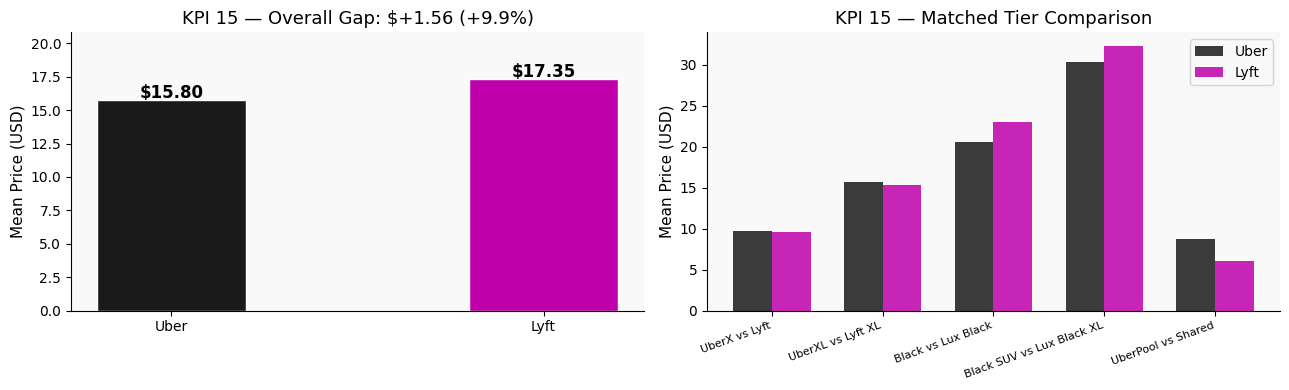

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(['Uber','Lyft'], [uber_mean,lyft_mean],
                   color=[UBER,LYFT], width=0.4, edgecolor='white')
for bar, val in zip(bars, [uber_mean,lyft_mean]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'${val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title(f'KPI 15 — Overall Gap: ${diff_abs:+.2f} ({diff_pct:+.1f}%)')
axes[0].set_ylabel('Mean Price (USD)')
axes[0].set_ylim(0, max(uber_mean,lyft_mean)*1.2)

if len(kpi15) > 0:
    x = range(len(kpi15))
    w = 0.35
    axes[1].bar([xi-w/2 for xi in x], kpi15['uber_mean'], w, label='Uber', color=UBER, alpha=0.85)
    axes[1].bar([xi+w/2 for xi in x], kpi15['lyft_mean'], w, label='Lyft', color=LYFT, alpha=0.85)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(
        [f"{r['uber_tier']} vs {r['lyft_tier']}" for _,r in kpi15.iterrows()],
        fontsize=8, rotation=20, ha='right')
    axes[1].set_title('KPI 15 — Matched Tier Comparison')
    axes[1].set_ylabel('Mean Price (USD)')
    axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi15_price_differential.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 15 Summary — Platform Price Differential**
>
> Overall Lyft is **$1.56 more expensive (+9.9%)**, but this hides a nuanced picture. At economy level, **Uber is actually slightly more expensive** than Lyft (UberX $9.77 vs Lyft $9.61, UberPool $8.75 vs Shared $6.03). The Lyft premium is entirely driven by **luxury tiers** — Lux Black costs $2.54 more than Uber Black (+12.4%) and Lux Black XL costs $2.03 more than Black SUV (+6.7%). Budget-conscious riders should choose Uber for premium rides and Lyft for shared/economy rides.

## KPI 16 — Premium Segment Differential

In [33]:
uber_prem = df[df['name'].isin(['Black','Black SUV'])]['price'].mean()
lyft_prem = df[df['name'].isin(['Lux Black','Lux Black XL'])]['price'].mean()
prem_diff_abs = lyft_prem - uber_prem
prem_diff_pct = prem_diff_abs / uber_prem * 100

uber_econ  = df[df['name'].isin(['UberX','UberPool'])]['price'].mean()
lyft_econ  = df[df['name'].isin(['Lyft','Shared'])]['price'].mean()
uber_ratio = uber_prem / uber_econ
lyft_ratio = lyft_prem / lyft_econ

print(f'KPI 16 — Premium Segment Differential')
print(f'  Uber premium mean : ${uber_prem:.2f}')
print(f'  Lyft premium mean : ${lyft_prem:.2f}')
print(f'  Differential      : ${prem_diff_abs:+.2f}  ({prem_diff_pct:+.1f}%)')
print(f'  Uber premium/economy ratio: {uber_ratio:.2f}x')
print(f'  Lyft premium/economy ratio: {lyft_ratio:.2f}x')

kpi_results['KPI16_premium_diff_pct']        = round(prem_diff_pct, 2)
kpi_results['KPI16_uber_premium_econ_ratio'] = round(uber_ratio, 2)
kpi_results['KPI16_lyft_premium_econ_ratio'] = round(lyft_ratio, 2)

KPI 16 — Premium Segment Differential
  Uber premium mean : $25.41
  Lyft premium mean : $27.69
  Differential      : $+2.29  (+9.0%)
  Uber premium/economy ratio: 2.74x
  Lyft premium/economy ratio: 3.54x


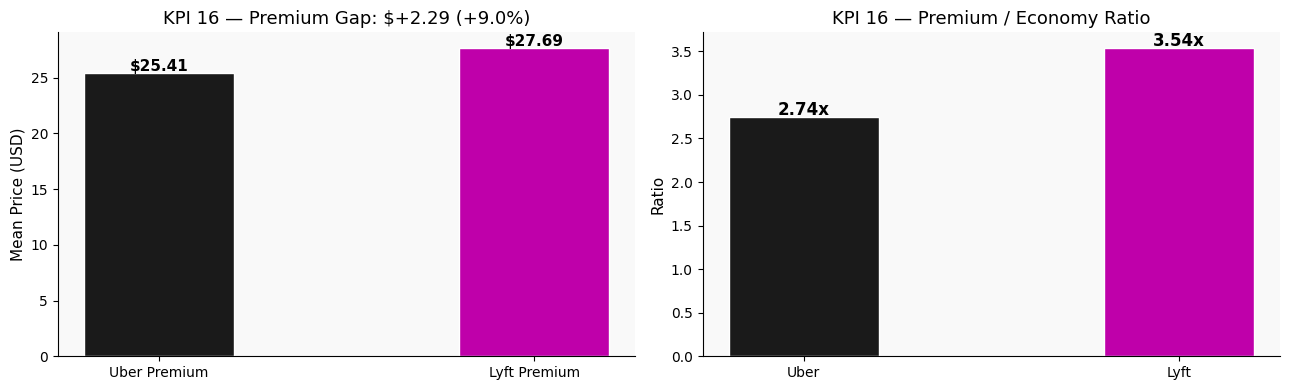

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(['Uber Premium','Lyft Premium'], [uber_prem,lyft_prem],
                   color=[UBER,LYFT], width=0.4, edgecolor='white')
for bar, val in zip(bars,[uber_prem,lyft_prem]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'${val:.2f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title(f'KPI 16 — Premium Gap: ${prem_diff_abs:+.2f} ({prem_diff_pct:+.1f}%)')
axes[0].set_ylabel('Mean Price (USD)')

bars2 = axes[1].bar(['Uber','Lyft'], [uber_ratio,lyft_ratio],
                    color=[UBER,LYFT], width=0.4, edgecolor='white')
for bar, val in zip(bars2,[uber_ratio,lyft_ratio]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.2f}x', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('KPI 16 — Premium / Economy Ratio')
axes[1].set_ylabel('Ratio')

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi16_premium_segment.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 16 Summary — Premium Segment Differential**
>
> Lyft's premium mean ($27.69) is **$2.29 higher (+9%)** than Uber's ($25.41). More revealing is the **premium/economy ratio** — Lyft premium costs 3.54x its economy tier, while Uber premium costs only 2.74x. This means Lyft has a **wider tier spread**: its luxury services are proportionally far more expensive compared to its own base tier than Uber's are. Lyft positions its premium tiers more aggressively, while Uber maintains a flatter pricing structure across tiers.

## KPI 17 — Competitive Advantage Window

In [35]:
hourly = (
    df.groupby(['cab_type','hour'], observed=True)['price'].mean()
    .unstack('cab_type').round(2)
)
hourly['cheaper'] = hourly.apply(lambda r: 'Uber' if r['Uber']<r['Lyft'] else 'Lyft', axis=1)
hourly['gap']     = (hourly['Lyft'] - hourly['Uber']).round(2)

uber_cheaper = hourly[hourly['cheaper']=='Uber'].index.tolist()
lyft_cheaper = hourly[hourly['cheaper']=='Lyft'].index.tolist()

print('KPI 17 — Competitive Advantage Window')
print(hourly)
print(f'\n  Uber cheaper: {len(uber_cheaper)} hours — {uber_cheaper}')
print(f'  Lyft cheaper: {len(lyft_cheaper)} hours — {lyft_cheaper}')

kpi_results['KPI17_uber_cheaper_hours'] = len(uber_cheaper)
kpi_results['KPI17_lyft_cheaper_hours'] = len(lyft_cheaper)

KPI 17 — Competitive Advantage Window
cab_type    Lyft    Uber cheaper    gap
hour                                   
0        17.4500 15.7300    Uber 1.7200
1        17.3100 15.7700    Uber 1.5400
2        17.3200 15.8700    Uber 1.4500
3        17.3500 15.7900    Uber 1.5600
4        17.3700 15.8600    Uber 1.5100
5        17.3300 15.7900    Uber 1.5400
6        17.2800 15.8300    Uber 1.4500
7        17.3200 15.7300    Uber 1.5900
8        17.4000 15.8700    Uber 1.5300
9        17.2600 15.8100    Uber 1.4500
10       17.3100 15.7600    Uber 1.5500
11       17.5000 15.6900    Uber 1.8100
12       17.3300 15.6900    Uber 1.6400
13       17.3500 15.8000    Uber 1.5500
14       17.3600 15.8100    Uber 1.5500
15       17.3400 15.7700    Uber 1.5700
16       17.3600 15.7400    Uber 1.6200
17       17.3800 15.8600    Uber 1.5200
18       17.2400 15.8500    Uber 1.3900
19       17.3800 15.7500    Uber 1.6300
20       17.3900 15.8800    Uber 1.5100
21       17.3300 15.9100    Uber 1.4200
22

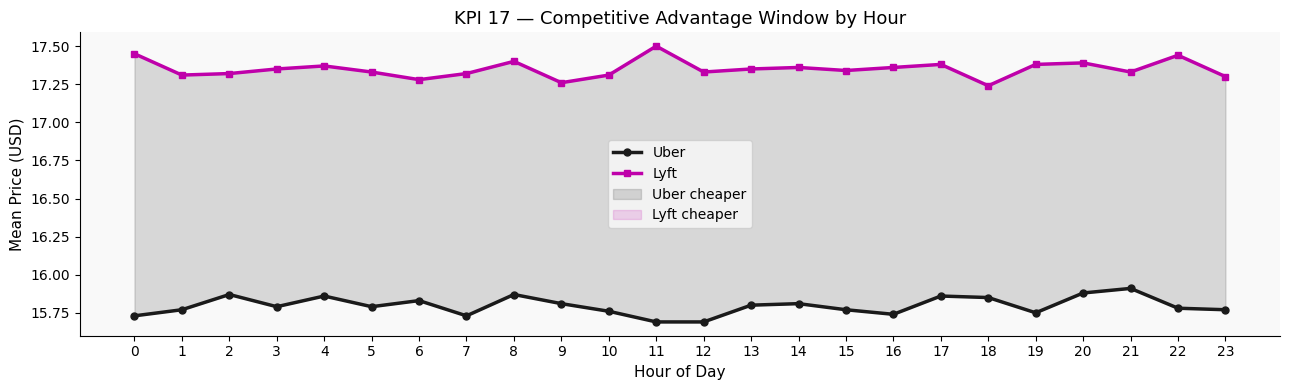

In [36]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(hourly.index, hourly['Uber'], color=UBER, linewidth=2.5, marker='o', markersize=5, label='Uber')
ax.plot(hourly.index, hourly['Lyft'], color=LYFT, linewidth=2.5, marker='s', markersize=5, label='Lyft')
ax.fill_between(hourly.index, hourly['Uber'], hourly['Lyft'],
                where=(hourly['Uber']<hourly['Lyft']),
                alpha=0.15, color=UBER, label='Uber cheaper')
ax.fill_between(hourly.index, hourly['Uber'], hourly['Lyft'],
                where=(hourly['Lyft']<hourly['Uber']),
                alpha=0.15, color=LYFT, label='Lyft cheaper')
ax.set_title('KPI 17 — Competitive Advantage Window by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Price (USD)')
ax.set_xticks(range(0, 24))
ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/kpi_charts/kpi17_competitive_window.png', dpi=150, bbox_inches='tight')
plt.show()

> **KPI 17 Summary — Competitive Advantage Window**
>
> **Uber is cheaper at every single hour of the day** — all 24 hours. The gap ranges from $1.45 to $1.81, with the widest gap at 11:00 ($1.81) coinciding with Lyft's price peak hour. There is **no hour window where Lyft is the cheaper option** on a like-for-like all-tiers comparison. For cost-sensitive riders, Uber wins at every time of day. For Lyft to compete on price, it would need to either lower its luxury pricing or shift its tier mix — its economy tiers are already competitive or cheaper than Uber's equivalents.

---
# Final Summary — All 17 KPIs

In [37]:
print('=' * 62)
print('  ALL 17 KPI RESULTS — UBER & LYFT | BOSTON MA')
print('=' * 62)
print()
print('── A. BASE PRICING ──────────────────────────────────────────')
print(f'  KPI 01 | Mean price     Uber: ${kpi_results["KPI01_uber_mean"]:.2f}  |  Lyft: ${kpi_results["KPI01_lyft_mean"]:.2f}')
print(f'  KPI 02 | See tier breakdown above')
print(f'  KPI 03 | Price/km       Uber: ${kpi_results["KPI03_uber_price_per_km"]:.2f}  |  Lyft: ${kpi_results["KPI03_lyft_price_per_km"]:.2f}')
print(f'  KPI 04 | Volatility CV% Uber: {kpi_results["KPI04_uber_cv_pct"]:.1f}%  |  Lyft: {kpi_results["KPI04_lyft_cv_pct"]:.1f}%')
print()
print('── B. SURGE PRICING (Lyft only) ─────────────────────────────')
print(f'  KPI 05 | Surge frequency      : {kpi_results["KPI05_lyft_surge_rate_pct"]:.2f}%')
print(f'  KPI 06 | Avg surge multiplier : {kpi_results["KPI06_avg_surge_multiplier"]:.3f}x')
print(f'  KPI 07 | Surge premium        : +${kpi_results["KPI07_surge_premium_abs"]:.2f}  (+{kpi_results["KPI07_surge_premium_pct"]:.1f}%)')
print(f'  KPI 08 | Peak surge hour      : {kpi_results["KPI08_peak_surge_hour"]}:00  ({kpi_results["KPI08_peak_surge_rate_pct"]:.1f}%)')
print()
print('── C. TEMPORAL PATTERNS ─────────────────────────────────────')
print(f'  KPI 09 | Price peak hour  Uber: {kpi_results["KPI09_uber_peak_hour"]}:00  |  Lyft: {kpi_results["KPI09_lyft_peak_hour"]}:00')
print(f'  KPI 10 | Weekend premium  Uber: {kpi_results["KPI10_uber_weekend_gap_pct"]:+.1f}%  |  Lyft: {kpi_results["KPI10_lyft_weekend_gap_pct"]:+.1f}%')
print(f'  KPI 11 | Peak demand day  : {kpi_results["KPI11_peak_day"]}')
print()
print('── D. WEATHER IMPACT ────────────────────────────────────────')
print(f'  KPI 12 | Temp-price corr  Uber: {kpi_results["KPI12_temp_corr_uber"]:.4f}  |  Lyft: {kpi_results["KPI12_temp_corr_lyft"]:.4f}')
print(f'  KPI 13 | Rain premium     Uber: ${kpi_results["KPI13_uber_rain_premium"]:+.2f}  |  Lyft: ${kpi_results["KPI13_lyft_rain_premium"]:+.2f}')
print(f'  KPI 14 | Peak surge weather: {kpi_results["KPI14_max_surge_weather"]}  ({kpi_results["KPI14_max_surge_weather_pct"]:.1f}%)')
print()
print('── E. COMPETITIVE ───────────────────────────────────────────')
print(f'  KPI 15 | Platform diff        : ${kpi_results["KPI15_price_diff_abs"]:+.2f}  ({kpi_results["KPI15_price_diff_pct"]:+.1f}%)')
print(f'  KPI 16 | Premium diff         : {kpi_results["KPI16_premium_diff_pct"]:+.1f}%  |  Uber: {kpi_results["KPI16_uber_premium_econ_ratio"]:.2f}x  Lyft: {kpi_results["KPI16_lyft_premium_econ_ratio"]:.2f}x')
print(f'  KPI 17 | Competitive window   : Uber cheaper {kpi_results["KPI17_uber_cheaper_hours"]}h  |  Lyft cheaper {kpi_results["KPI17_lyft_cheaper_hours"]}h')
print()
print('=' * 62)

  ALL 17 KPI RESULTS — UBER & LYFT | BOSTON MA

── A. BASE PRICING ──────────────────────────────────────────
  KPI 01 | Mean price     Uber: $15.80  |  Lyft: $17.35
  KPI 02 | See tier breakdown above
  KPI 03 | Price/km       Uber: $6.02  |  Lyft: $6.01
  KPI 04 | Volatility CV% Uber: 54.2%  |  Lyft: 57.7%

── B. SURGE PRICING (Lyft only) ─────────────────────────────
  KPI 05 | Surge frequency      : 6.82%
  KPI 06 | Avg surge multiplier : 1.458x
  KPI 07 | Surge premium        : +$11.25  (+67.9%)
  KPI 08 | Peak surge hour      : 13:00  (8.0%)

── C. TEMPORAL PATTERNS ─────────────────────────────────────
  KPI 09 | Price peak hour  Uber: 21:00  |  Lyft: 11:00
  KPI 10 | Weekend premium  Uber: +0.1%  |  Lyft: +0.3%
  KPI 11 | Peak demand day  : Tue

── D. WEATHER IMPACT ────────────────────────────────────────
  KPI 12 | Temp-price corr  Uber: 0.0017  |  Lyft: -0.0020
  KPI 13 | Rain premium     Uber: $+0.03  |  Lyft: $-0.06
  KPI 14 | Peak surge weather: Foggy  (7.8%)

── E. COMPE